# Thiranex Internship — Task 2
## Data Cleaning & Visualization

**Project:** Retail Sales Data Cleaning and Business Insights  
**Dataset:** UCI Machine Learning Repository — Online Retail  
**Objective:** Clean a raw retail transaction dataset, transform it for analysis, visualize important patterns, and summarize business findings.

This notebook is structured as an internship-ready submission and explains the cleaning decisions instead of blindly deleting records.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 2. Load the Raw Dataset

In [2]:
file_path = "Online Retail.xlsx"
df = pd.read_excel(file_path)

print(f"Dataset loaded successfully: {file_path}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully: Online Retail.xlsx
Rows: 541,909
Columns: 8


## 3. Initial Data Inspection

Before cleaning, we inspect the first records, dimensions, data types, missing values, duplicates, and descriptive statistics.


In [3]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))
print("\nDuplicate rows:", df.duplicated().sum())


Dataset shape: (541909, 8)

Missing values:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Duplicate rows: 5268


In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Quality Investigation

The raw data contains issues that need investigation:
- Exact duplicate rows
- Missing product descriptions
- Missing customer IDs
- Non-positive quantities
- Non-positive unit prices
- Cancellation invoices (invoice numbers beginning with `C`)

The goal is to distinguish ordinary sales records from records that should not be included in a positive-sales analysis.


In [7]:
cancelled_invoices = df["InvoiceNo"].astype(str).str.startswith("C").sum()
non_positive_quantity = (df["Quantity"] <= 0).sum()
non_positive_price = (df["UnitPrice"] <= 0).sum()
duplicate_rows = df.duplicated().sum()

quality_summary = pd.DataFrame({
    "Issue": [
        "Duplicate rows",
        "Missing Description",
        "Missing CustomerID",
        "Cancellation invoices (InvoiceNo starts with C)",
        "Quantity <= 0",
        "UnitPrice <= 0"
    ],
    "Count": [
        duplicate_rows,
        df["Description"].isna().sum(),
        df["CustomerID"].isna().sum(),
        cancelled_invoices,
        non_positive_quantity,
        non_positive_price
    ]
})

quality_summary


,Issue,Count
0,Duplicate rows,5268
1,Missing Description,1454
2,Missing CustomerID,135080
3,Cancellation invoices (InvoiceNo starts with C),9288
4,Quantity <= 0,10624
5,UnitPrice <= 0,2517


## 5. Data Cleaning

**Cleaning decisions**

1. Remove exact duplicate rows.
2. Fill missing product descriptions with `Unknown Product` so usable transaction rows are not unnecessarily lost.
3. Convert `InvoiceDate` to datetime.
4. Keep only `Quantity > 0` and `UnitPrice > 0` for the normal-sales analysis. Non-positive quantities include returns/cancellations and are not ordinary positive sales.
5. Keep missing `CustomerID` values because customer identification is not required for overall time, country, and product revenue analysis. Customer-level analysis can filter to known customer IDs separately.


In [8]:
clean_df = df.drop_duplicates().copy()

clean_df["Description"] = clean_df["Description"].fillna("Unknown Product")
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

clean_df = clean_df[
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
].copy()

print(f"Original rows: {len(df):,}")
print(f"Cleaned rows:  {len(clean_df):,}")
print(f"Rows removed:  {len(df) - len(clean_df):,}")


Original rows: 541,909
Cleaned rows:  524,878
Rows removed:  17,031


## 6. Feature Engineering

Revenue is calculated as:

**Revenue = Quantity × UnitPrice**

Time features are also created for monthly and weekday analysis.


In [9]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]
clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M").astype(str)
clean_df["Weekday"] = clean_df["InvoiceDate"].dt.day_name()

clean_df[[
    "InvoiceNo", "Description", "Quantity", "UnitPrice",
    "InvoiceDate", "Revenue", "Country"
]].head()


,InvoiceNo,Description,Quantity,UnitPrice,InvoiceDate,Revenue,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,2010-12-01 08:26:00,15.30,United Kingdom
1,536365,WHITE METAL LANTERN,6,3.39,2010-12-01 08:26:00,20.34,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,2010-12-01 08:26:00,22.00,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,2010-12-01 08:26:00,20.34,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,2010-12-01 08:26:00,20.34,United Kingdom


## 7. Cleaned Dataset Validation

In [10]:
print("Cleaned dataset shape:", clean_df.shape)
print("\nMissing values after cleaning:")
display(clean_df.isnull().sum().to_frame("Missing Values"))
print("\nDuplicate rows after cleaning:", clean_df.duplicated().sum())
print("Non-positive quantities:", (clean_df["Quantity"] <= 0).sum())
print("Non-positive prices:", (clean_df["UnitPrice"] <= 0).sum())


Cleaned dataset shape: (524878, 12)

Missing values after cleaning:


,Missing Values
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132186
Country,0
Revenue,0
Year,0



Duplicate rows after cleaning: 0
Non-positive quantities: 0
Non-positive prices: 0


## 8. Visualization — Monthly Revenue

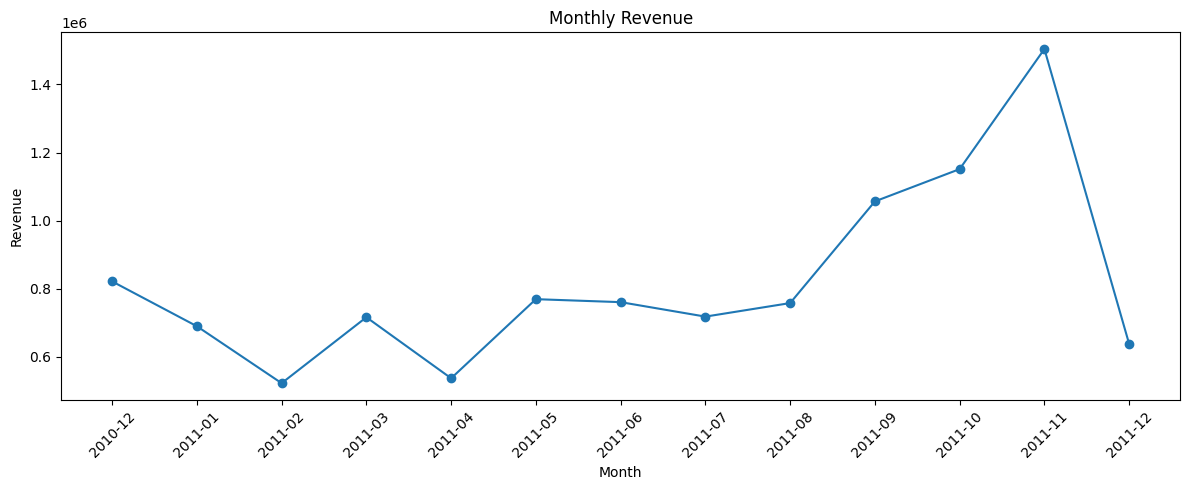

In [11]:
monthly_revenue = clean_df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Visualization — Top 10 Countries by Revenue

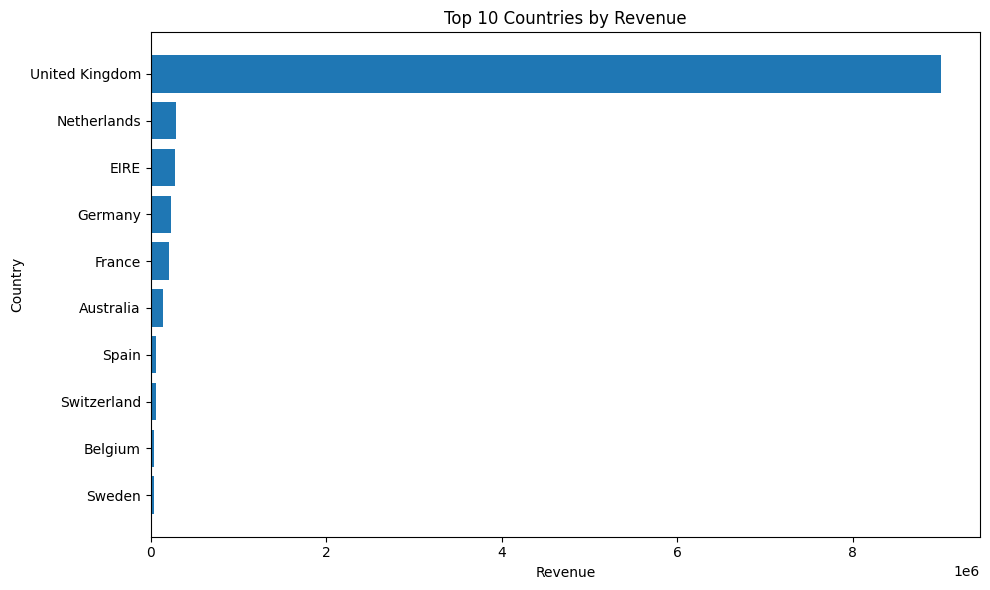

In [12]:
country_revenue = (
    clean_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(country_revenue.index[::-1], country_revenue.values[::-1])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## 10. Visualization — Top 10 Products by Revenue

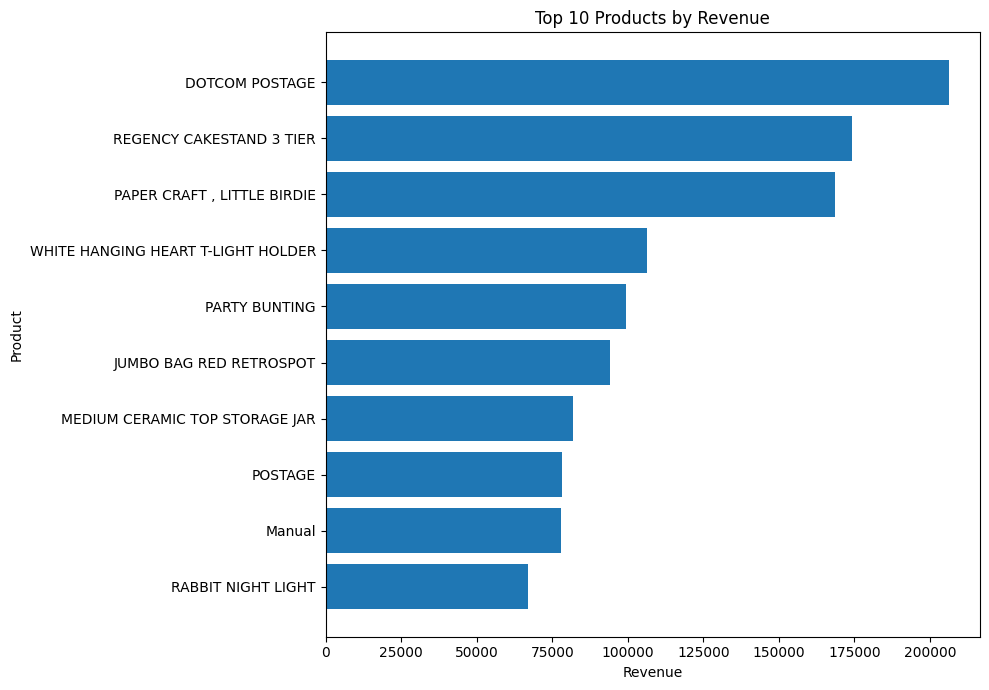

In [13]:
product_revenue = (
    clean_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 7))
plt.barh(product_revenue.index[::-1], product_revenue.values[::-1])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


## 11. Visualization — Quantity Distribution

Very large quantities can distort a chart. The histogram below focuses on values up to the 99th percentile so the main distribution remains readable.


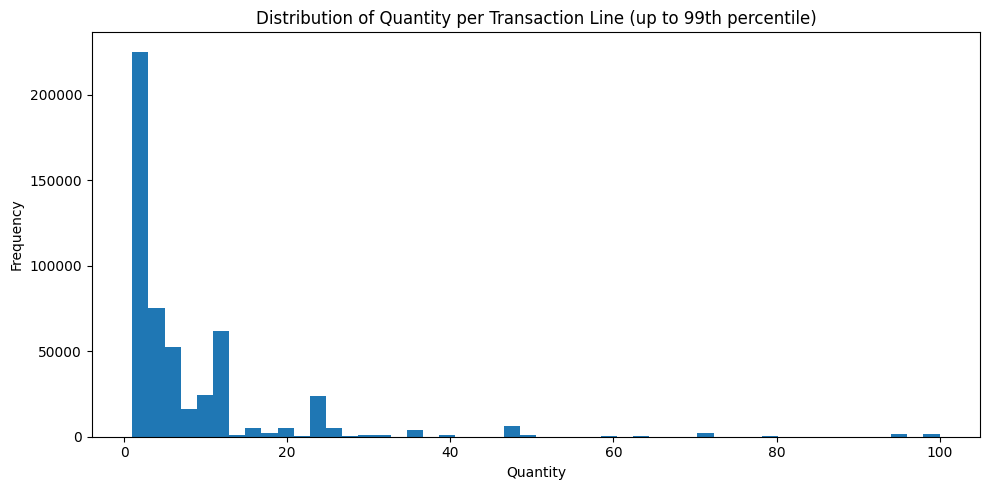

In [14]:
quantity_limit = clean_df["Quantity"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(clean_df.loc[clean_df["Quantity"] <= quantity_limit, "Quantity"], bins=50)
plt.title("Distribution of Quantity per Transaction Line (up to 99th percentile)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 12. Key Business Metrics

In [15]:
total_revenue = clean_df["Revenue"].sum()
total_units = clean_df["Quantity"].sum()
unique_invoices = clean_df["InvoiceNo"].nunique()
unique_products = clean_df["StockCode"].nunique()
unique_countries = clean_df["Country"].nunique()

metrics = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Units Sold",
        "Unique Invoices",
        "Unique Products",
        "Countries"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_units:,.0f}",
        f"{unique_invoices:,}",
        f"{unique_products:,}",
        f"{unique_countries:,}"
    ]
})

metrics


,Metric,Value
0,Total Revenue,"£10,642,110.80"
1,Total Units Sold,"5,572,420"
2,Unique Invoices,"19,960"
3,Unique Products,"3,922"
4,Countries,38


## 13. Key Findings

In [16]:
top_country = country_revenue.index[0]
top_country_revenue = country_revenue.iloc[0]
top_product = product_revenue.index[0]
top_product_revenue = product_revenue.iloc[0]
best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

print(f"1. Highest-revenue country: {top_country} — £{top_country_revenue:,.2f}.")
print(f"2. Highest-revenue product: {top_product} — £{top_product_revenue:,.2f}.")
print(f"3. Strongest month by revenue: {best_month} — £{best_month_revenue:,.2f}.")
print(f"4. Valid positive-sales transaction lines after cleaning: {len(clean_df):,}.")
print(f"5. Total calculated revenue from valid sales: £{total_revenue:,.2f}.")


1. Highest-revenue country: United Kingdom — £9,001,744.09.
2. Highest-revenue product: DOTCOM POSTAGE — £206,248.77.
3. Strongest month by revenue: 2011-11 — £1,503,866.78.
4. Valid positive-sales transaction lines after cleaning: 524,878.
5. Total calculated revenue from valid sales: £10,642,110.80.


## 14. Conclusion

This project demonstrates an end-to-end data cleaning and visualization workflow:

- Loaded a large raw retail transaction dataset.
- Inspected structure, data types, missing values, duplicates, and descriptive statistics.
- Investigated cancellations and invalid sales values.
- Removed duplicate and invalid records using explicit rules.
- Handled missing product descriptions while preserving usable transactions.
- Created revenue and time-based features.
- Visualized monthly revenue, country revenue, product revenue, and quantity distribution.
- Extracted business-oriented findings from the cleaned data.

The resulting dataset is suitable for reliable sales analysis and provides a strong foundation for later machine-learning work.


## Dataset Source

UCI Machine Learning Repository — Online Retail  
https://archive.ics.uci.edu/dataset/352/online+retail

**Prepared for:** Thiranex Internship — Task 2: Data Cleaning & Visualization
